# Quickstart: Querying PDF With Astra and LangChain

### A question-answering demo using Astra DB and LangChain, powered by Vector Search

#### Pre-requisites:

You need a **_Serverless Cassandra with Vector Search_** database on [Astra DB](https://astra.datastax.com) to run this demo. As outlined in more detail [here](https://docs.datastax.com/en/astra-serverless/docs/vector-search/quickstart.html#_prepare_for_using_your_vector_database), you should get a DB Token with role _Database Administrator_ and copy your Database ID: these connection parameters are needed momentarily.

You also need an [OpenAI API Key](https://cassio.org/start_here/#llm-access) for this demo to work.

#### What you will do:

- Setup: import dependencies, provide secrets, create the LangChain vector store;
- Run a Question-Answering loop retrieving the relevant headlines and having an LLM construct the answer.

Install the required dependencies:

In [ ]:
import sys

## Just some imports
!"{sys.executable}" -m pip install datasets cassio

  Using cached datasets-4.8.5-py3-none-any.whl.metadata (19 kB)
  Using cached cassio-0.1.10-py3-none-any.whl.metadata (4.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached multiprocess-0.70.19-py313-none-any.whl.metadata (7.5 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached cassandra_driver-3.30.0-cp313-cp313-win_amd64.whl.metadata (6.9 kB)
  Using cached geomet-1.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
Using cached datasets-4.8.5-py3-none-any.whl (528 kB)
Using cached dill-0.4.1-py3-none-any.whl (120 kB)
Using cached fsspec-2026.2.0-py3-none-any.whl (202 kB)
Using cached multiprocess-0.70.19-py313-none-any.whl (156 kB)
Using cached cassio-0.1.10-py3-none-any.whl (45 kB)
Using cached cassandra_driver-3.30.0-cp313-cp313-win_amd64.whl (6.8 MB)
Using cached deprecated-1.3.1-py2.py3-none-any.whl (11 kB)
Using cached geomet-1.1.0-py3-none-any.whl (31 kB)

  

In [ ]:
## Just some more imports
!"{sys.executable}" -m pip install pyasyncore

Import the packages you'll need:

In [ ]:
## LangChain components to use
from langchain_classic.vectorstores.cassandra import Cassandra
from langchain_classic.indexes.vectorstore import VectorStoreIndexWrapper
from langchain_ollama import OllamaEmbeddings

import warnings
warnings.filterwarnings('ignore')

## Support for dataset retrieval with Hugging Face
from datasets import load_dataset

## With CassIO, the engine powering the Astra DB integration in LangChain,
## you will also initialize the DB connection:
import cassio

## Import the PDF loader
from pypdf import PdfReader

### Setup

In [9]:
## Enter your AstraDB token
ASTRA_DB_APPLICATION_TOKEN = "AstraCS:oHpcpaCnMLZvNLZuPmvXkyPf:363f85e857db76cb8d823cf1347be9362c5413575616070508671823ea15000d" # enter the "AstraCS:..." string found in in your Token JSON file

## Enter your Database ID
ASTRA_DB_ID = "0e77f565-7447-45ba-876a-c4ea2874790d" 

## Enter your Groq API key
GROQ_API_KEY = "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"

#### Provide your secrets:

Replace the following with your Astra DB connection details and your OpenAI API key:

In [11]:
## Provide the path of pdf file/files.
pdfreader = PdfReader('sample_pdf.pdf')
pdfreader

In [12]:
from typing_extensions import Concatenate

## read text from pdf
raw_text = ''
for i, page in enumerate(pdfreader.pages):
    content = page.extract_text()
    if content:
        raw_text += content

print(raw_text)

Modern Data Analytics
Martial Luyts
Catholic University of Leuven, Belgium
martial.luyts@kuleuven.be
Contents
0. Introduction . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1
0.1. Goal & organisation of the course . . . . . . . . . . . . . . . . . . . . . . . . 2
0.2. Scheme . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 4
0.3. Evaluation & deadlines . . . . . . . . . . . . . . . . . . . . . . . . . . . . 5
0.4. Use of GenAI for this course . . . . . . . . . . . . . . . . . . . . . . . . . . 8
0.5. Questions? . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 10
1. Python Fundamentals for Data Scientists . . . . . . . . . . . . . . 11
1.1. Python . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 12
i1.2. Writing Code . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 18
1.3. Google Colab . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 31
1.4. Git, Github & Hugging Face . . . . . . . . . 

Initialize the connection to your database:

_(do not worry if you see a few warnings, it's just that the drivers are chatty about negotiating protocol versions with the DB.)_

In [ ]:
## Initialize the cassio DB
cassio.init(token = ASTRA_DB_APPLICATION_TOKEN, database_id = ASTRA_DB_ID)

Create the LangChain embedding and LLM objects for later usage:

In [ ]:
from langchain_groq import ChatGroq
from langchain_classic.text_splitter import CharacterTextSplitter

## Import the LLM Groq
llm = ChatGroq(
    model = "llama-3.3-70b-versatile",
    api_key = GROQ_API_KEY,
    temperature = 0
)

## Get the Ollama Embeddings
embeddings = OllamaEmbeddings(model = "qwen2.5:1.5b")

## Create the vector store with AstraDB
astra_vector_store = Cassandra(embedding = embeddings, table_name = "qa_mini_demo", session = None, keyspace = None)

In [ ]:
## We need to split the text using CharacterTextSplitter such that it sshould not increse token size
text_splitter = CharacterTextSplitter(
    separator = "\n", chunk_size = 800,
    chunk_overlap  = 200, length_function = len,
)
texts = text_splitter.split_text(raw_text)
texts[:50]

['Modern Data Analytics\nMartial Luyts\nCatholic University of Leuven, Belgium\nmartial.luyts@kuleuven.be\nContents\n0. Introduction . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 1\n0.1. Goal & organisation of the course . . . . . . . . . . . . . . . . . . . . . . . . 2\n0.2. Scheme . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 4\n0.3. Evaluation & deadlines . . . . . . . . . . . . . . . . . . . . . . . . . . . . 5\n0.4. Use of GenAI for this course . . . . . . . . . . . . . . . . . . . . . . . . . . 8\n0.5. Questions? . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 10\n1. Python Fundamentals for Data Scientists . . . . . . . . . . . . . . 11\n1.1. Python . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 12',
 '1. Python Fundamentals for Data Scientists . . . . . . . . . . . . . . 11\n1.1. Python . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . . 12\ni1.2. Writing Code . . . . . . . . . . . .

### Load the dataset into the vector store



In [17]:
## Add the texts into the Vector DB
astra_vector_store.add_texts(texts[:50])

## Create the Vector Index with the help of wrapper
astra_vector_index = VectorStoreIndexWrapper(vectorstore = astra_vector_store)

### Run the QA cycle

Simply run the cells and ask a question!

In [18]:
## Run the QnA from the PDF
first_question = True
while True:
    if first_question:
        query_text = input("\nEnter your question (or type 'quit' to exit): ").strip()
    else:
        query_text = input("\nWhat's your next question (or type 'quit' to exit): ").strip()

    if query_text.lower() == "quit":
        break

    if query_text == "":
        continue

    first_question = False

    print("\nQUESTION: \"%s\"" % query_text)
    answer = astra_vector_index.query(query_text, llm=llm).strip()
    print("ANSWER: \"%s\"\n" % answer)

    print("FIRST DOCUMENTS BY RELEVANCE:")
    for doc, score in astra_vector_store.similarity_search_with_score(query_text, k=4):
        print("    [%0.4f] \"%s ...\"" % (score, doc.page_content[:84]))


QUESTION: "What do you mean by jupyer notebook?"
ANSWER: "Jupyter Notebook is an interactive web-based environment for working with Python code, visualizing data, and creating documents. It allows users to create and share documents that contain live code, equations, visualizations, and narrative text.

In the context of the provided text, Jupyter Notebook seems to be a tool used in the MDA course, and there are tutorials and resources available for learning how to use it, such as jupyter-notebook.readthedocs.io and realpython.com/jupyter-notebook-introduction.

Jupyter Notebook provides features like executing code cells, showing output, and navigating through cells using shortcuts like Shift-Enter and Ctrl-Enter. Additionally, extensions can be added to enhance its functionality."

FIRST DOCUMENTS BY RELEVANCE:
    [0.9435] "when the object is being cre-
ated.
• Remark 2: self parameter
is a reference to the ..."
    [0.9392] "environment.
• To set up a Python environment, the virtu

### Output on AstraDB

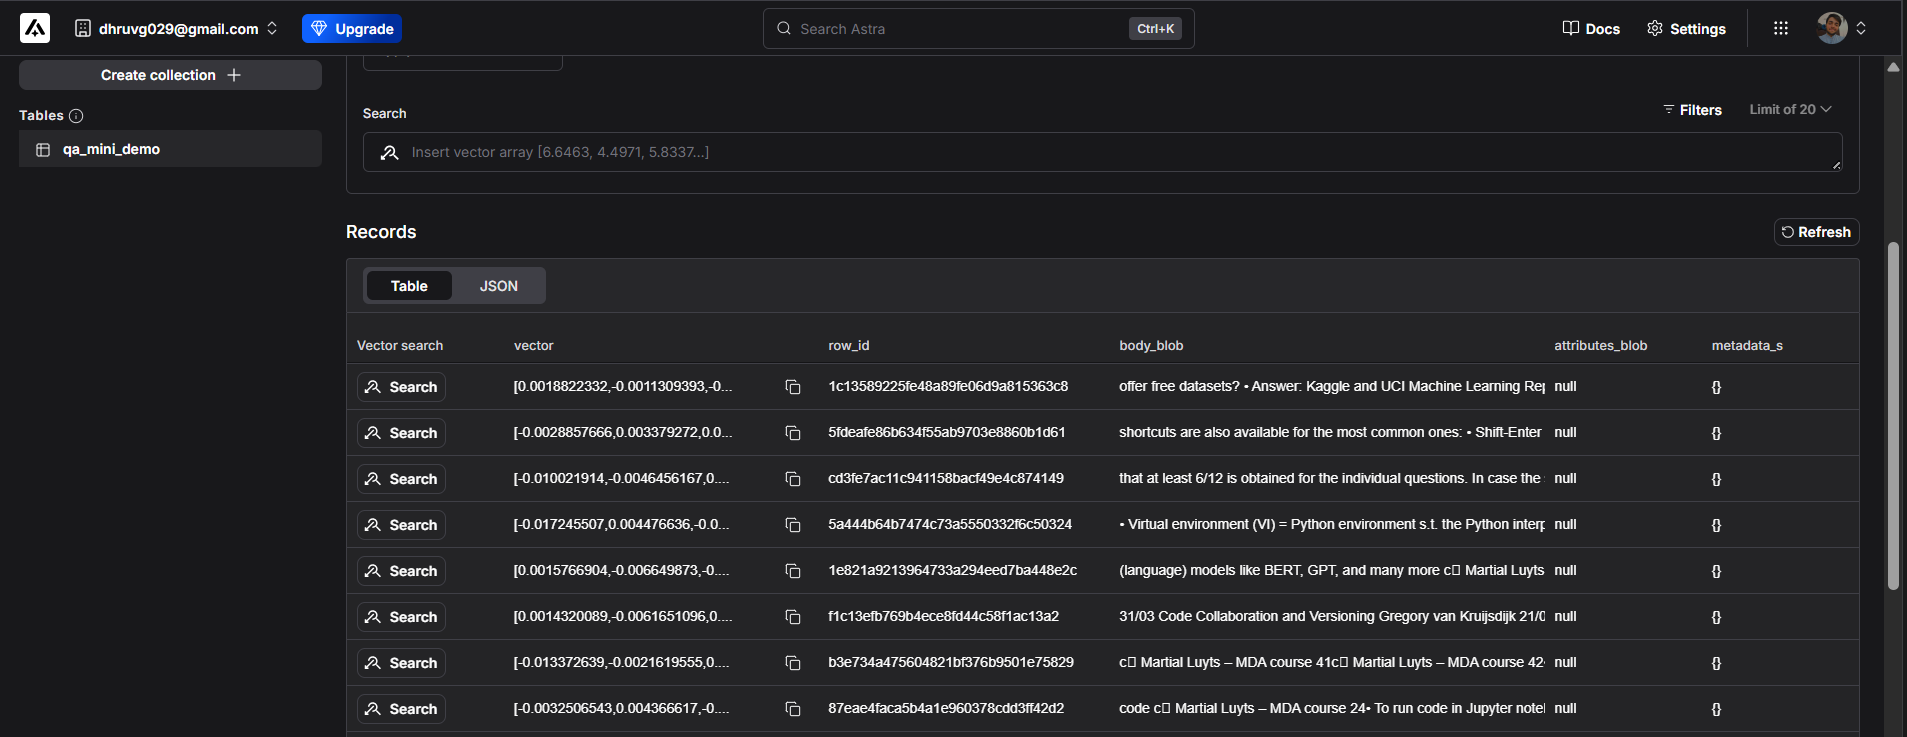